### Data Loading and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data_science_job.csv')

print("Shape:", df.shape)
print("\nFirst look:")
print(df.head(3))

Shape: (19158, 13)

First look:
   enrollee_id      city  city_development_index gender  \
0         8949  city_103                   0.920   Male   
1        29725   city_40                   0.776   Male   
2        11561   city_21                   0.624    NaN   

       relevent_experience enrolled_university education_level  \
0  Has relevent experience       no_enrollment        Graduate   
1   No relevent experience       no_enrollment        Graduate   
2   No relevent experience    Full time course        Graduate   

  major_discipline  experience company_size company_type  training_hours  \
0             STEM        20.0          NaN          NaN            36.0   
1             STEM        15.0        50-99      Pvt Ltd            47.0   
2             STEM         5.0          NaN          NaN            83.0   

   target  
0     1.0  
1     0.0  
2     0.0  


### 1. Checking for Missing Values

In [2]:
# isnull().mean()*100 → percentage of missing values per column
missing_pr = df.isnull().mean() * 100

print("Missing value % per column:")
print(missing_pr.round(2))

Missing value % per column:
enrollee_id                0.00
city                       0.00
city_development_index     2.50
gender                    23.53
relevent_experience        0.00
enrolled_university        2.01
education_level            2.40
major_discipline          14.68
experience                 0.34
company_size              30.99
company_type              32.05
training_hours             4.00
target                     0.00
dtype: float64


### 2. Select only Low missing datalevel Columns

In [9]:
# keep columns where missing % is between 0% and 5%
# (has SOME missing but not too much)

cols = [
    col for col in df.columns
    if df[col].isnull().mean() < 0.05    # less than 5% missing
    and df[col].isnull().mean() > 0      # but has at least some missing
]

print("Columns selected for CCA:")
print(cols)
print("\nMissing % for selected columns:")
print((df[cols].isnull().mean() * 100).round(2))
print(df[cols].info())


Columns selected for CCA:
['city_development_index', 'enrolled_university', 'education_level', 'experience', 'training_hours']

Missing % for selected columns:
city_development_index    2.50
enrolled_university       2.01
education_level           2.40
experience                0.34
training_hours            4.00
dtype: float64
<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  18679 non-null  float64
 1   enrolled_university     18772 non-null  str    
 2   education_level         18698 non-null  str    
 3   experience              19093 non-null  float64
 4   training_hours          18392 non-null  float64
dtypes: float64(3), str(2)
memory usage: 1.1 MB
None


### 3. Apply CCA (Drop Rows)

In [10]:
# check how many rows survive after dropping
survival_rate = len(df[cols].dropna()) / len(df)
print(f"Rows surviving CCA: {survival_rate*100:.1f}%")
print(f"Rows kept : {len(df[cols].dropna())}")
print(f"Rows lost : {len(df) - len(df[cols].dropna())}")

# apply CCA
new_df = df[cols].dropna()

print(f"\nBefore CCA: {df.shape}")
print(f"After CCA : {new_df.shape}")

Rows surviving CCA: 89.7%
Rows kept : 17182
Rows lost : 1976

Before CCA: (19158, 13)
After CCA : (17182, 5)


### 4. Compare Distributions

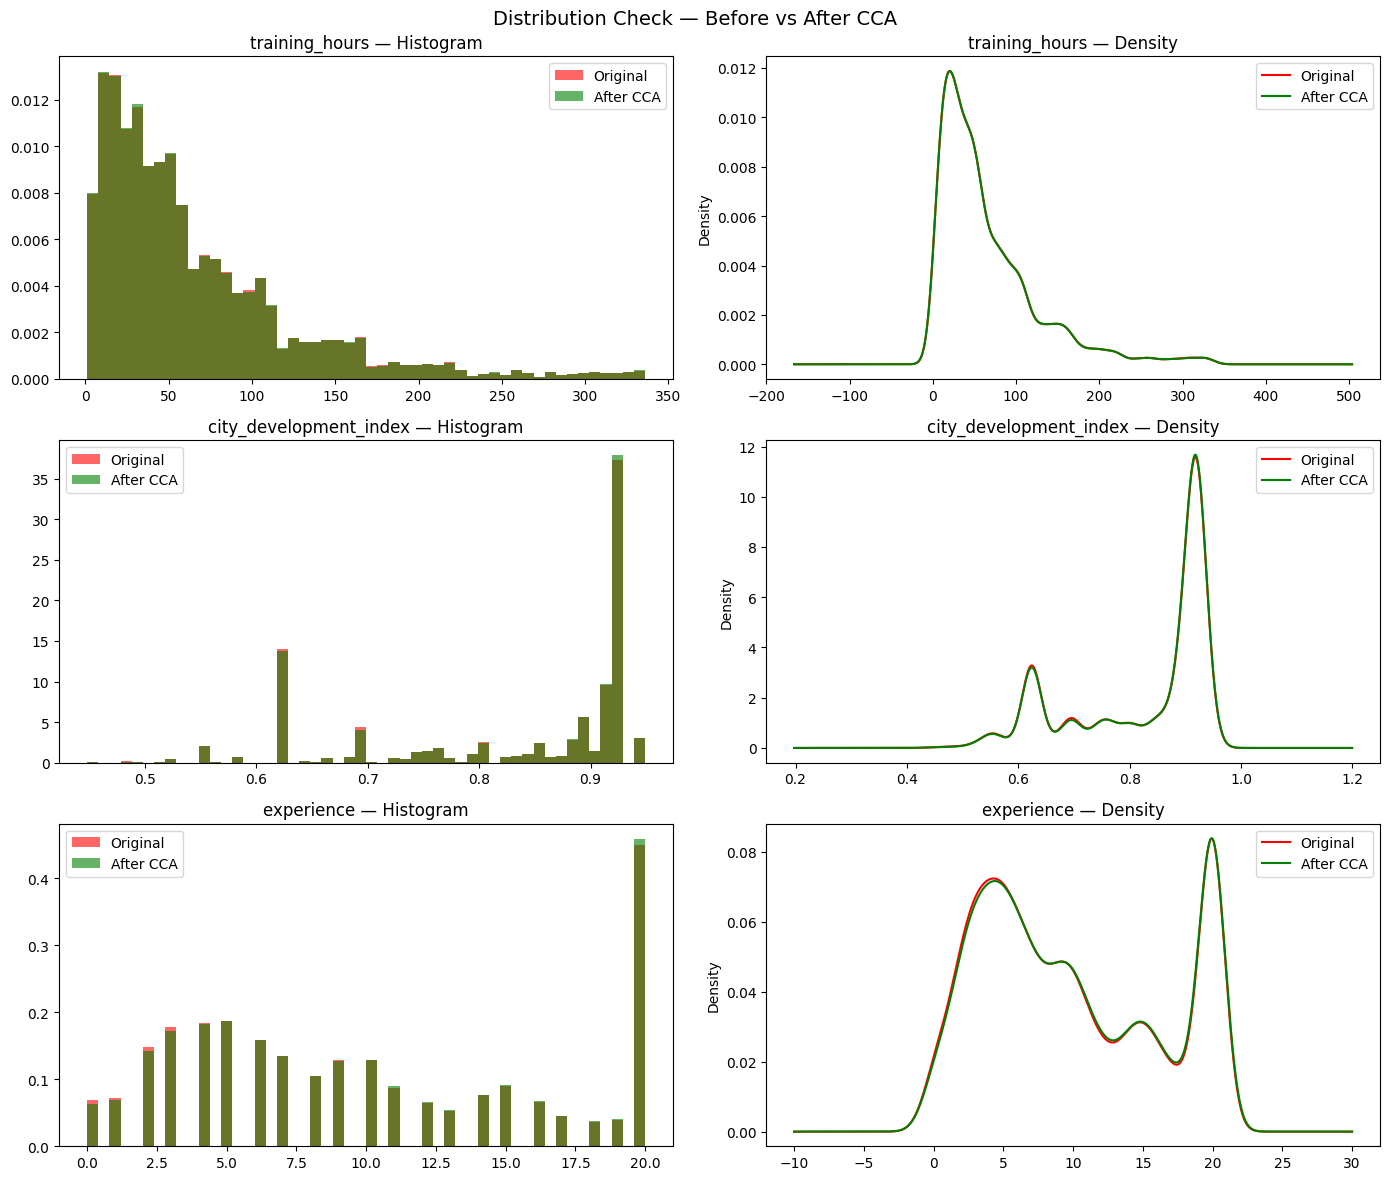

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Distribution Check — Before vs After CCA", fontsize=14)

numerical_cols = ['training_hours', 'city_development_index', 'experience']

for i, col in enumerate(numerical_cols):
    # histogram comparison
    axes[i][0].hist(df[col].dropna(),    bins=50, density=True,
                    color='red',   alpha=0.6, label='Original')
    axes[i][0].hist(new_df[col],         bins=50, density=True,
                    color='green', alpha=0.6, label='After CCA')
    axes[i][0].set_title(f"{col} — Histogram")
    axes[i][0].legend()

    # KDE comparison
    df[col].dropna().plot.density(ax=axes[i][1], color='red',   label='Original')
    new_df[col].plot.density(     ax=axes[i][1], color='green', label='After CCA')
    axes[i][1].set_title(f"{col} — Density")
    axes[i][1].legend()

plt.tight_layout()
plt.show()

### 5. Check Categoricsl Distributions

In [12]:
categorical_cols = ['enrolled_university', 'education_level']

for col in categorical_cols:
    temp = pd.concat([
        df[col].value_counts(normalize=True),       # original proportions
        new_df[col].value_counts(normalize=True)    # after CCA proportions
    ], axis=1)

    temp.columns   = ['Original %', 'After CCA %']
    temp           = temp.mul(100).round(2)
    temp['Diff %'] = (temp['After CCA %'] - temp['Original %']).round(2)

    print(f"\n{col}:")
    print(temp)
    print(f"Max difference: {temp['Diff %'].abs().max():.2f}%")


enrolled_university:
                     Original %  After CCA %  Diff %
enrolled_university                                 
no_enrollment             73.60        73.52   -0.08
Full time course          20.01        20.07    0.06
Part time course           6.38         6.41    0.03
Max difference: 0.08%

education_level:
                 Original %  After CCA %  Diff %
education_level                                 
Graduate              62.03        61.98   -0.05
Masters               23.32        23.41    0.09
High School           10.79        10.74   -0.05
Phd                    2.21         2.21    0.00
Primary School         1.65         1.66    0.01
Max difference: 0.09%
